# **Cubo Gelatinoso**
Aprendizado de Máquina

Aluno: Caio Guimarães Marino - T26 <br> Docente: Daniel Roberto Cassar

### **Introdução**

A seguinte criatura a ser capturada trata-se do Cubo Gelatinoso, uma criatura lendária muito perigosa que habita a Catacumba da Escuridão Sombria. Ele pode ser capturado a partir da escolha de um conjunto de dados e do estudo do desempenho de modelos induzidos pelo algoritmo de k vizinhos mais próximos neste conjunto de dados considerando pelo menso 10 conjuntos de hiperparâmetros diferentes. <br> No caso desta tentativa de captura, usarei o modelo KNN para prever o attack de Pokémons a partir de outras stats e do tipo do Pokémon.



##### **Descrição do dataset**

O dataset escolhido foi retirado do Kaggle[1] e reúne informações sobre 801 pokémons, da 1ª a 7ª geração. O dataset original contém 41 colunas, no entanto, não seria necessário todas as colunas para realizar a previsão com KNN que eu queria, o que iria acabar atrapalhando o meu objetivo. Para resolver isso, com o auxílio do Claude (Anthropic), removi as colunas que não me interessavam para análise e fiquei apenas com o necessário. <br> Os atributos presentes no dataset são: *type1* e *type2 (atributos categóricos; este último será descartado posteriormente)*; *hp, defense, sp_attack, sp_defense, speed* (atributos numéricos). A coluna *name* e *generation* são apenas identificadores (o nome dos pokémons e sua geração) e não serão utilizados como atributos. Eu escolhi prever o attack dos pokémons a partir dos stats e tipos dos mesmos, visto que o attack não é uma soma de nada, o que torna a captura do Cubo Gelatinoso mais interessante e desafiadora, já que o modelo precisa aprender um padrão real em vez de só somar números como seria caso eu quisesse prever o *base_total* usando as stats individuais.

##### **Importação de Módulos**

Na célula abaixo, serão importados os módulos que serão utilizados no decorrer da captura do Cubo.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.dummy import DummyRegressor
from itertools import product

#### **Carregamento e Tratamento de dados**

##### **Importando o Dataset**

In [2]:
NOME_DATASET = "dataset_pokemon_simplificado.csv"
ATRIBUTOS = ["hp", "defense", "sp_attack", "sp_defense", "speed", "type1"]
TARGET = ["attack"]

df = pd.read_csv(NOME_DATASET)
df

,name,type1,type2,generation,hp,attack,defense,sp_attack,sp_defense,speed
0,Bulbasaur,grass,poison,1,45,49,49,65,65,45
1,Ivysaur,grass,poison,1,60,62,63,80,80,60
2,Venusaur,grass,poison,1,80,100,123,122,120,80
3,Charmander,fire,NaN,1,39,52,43,60,50,65
4,Charmeleon,fire,NaN,1,58,64,58,80,65,80
...,...,...,...,...,...,...,...,...,...,...
796,Celesteela,steel,flying,7,97,101,103,107,101,61
797,Kartana,grass,steel,7,59,181,131,59,31,109
798,Guzzlord,dark,dragon,7,223,101,53,97,53,43
799,Necrozma,psychic,NaN,7,97,107,101,127,89,79


Analisando o dataset acima, percebe-se que o atributo `type2` apresenta linhas com dados ausentes (NaN), o que faz com que seja necessário ou descartar a coluna ou converter o NaN para uma categoria válida ("nenhum", por exemplo), o que seria mais complexo. Mediante isso, minha decisão final é descartar a coluna `type2`, mesmo sabendo que isso influencia nos stats de Pokémons que apresentam dois tipos. Portanto, vale a pena levar isso em consideração na hora de realizar as previsões. <br> Além disso, é necessário converter a coluna `type1` (atributo categórico) em uma coluna binária, visto que o `scikit-learn` (módulo que será utilizado para treinar nosso algoritmo) não aceita string direto. Isso será feito por meio da técnica de `One-Hot Encoding`, a qual converte dados categóricos em dados numéricos, sem criar uma hierarquia falsa entre as opções.

##### **Tratando dados**

In [3]:
# Criando cópia do dataset
df_copia = df.copy()

# Removendo coluna type2
df_copia = df_copia.drop("type2", axis=1)

# One-Hot Enconding a partir do get dummies do pandas
df_pokemon = pd.get_dummies(df_copia, columns=["type1"])

df_pokemon

,name,generation,hp,attack,defense,sp_attack,sp_defense,speed,type1_bug,type1_dark,...,type1_ghost,type1_grass,type1_ground,type1_ice,type1_normal,type1_poison,type1_psychic,type1_rock,type1_steel,type1_water
0,Bulbasaur,1,45,49,49,65,65,45,False,False,...,False,True,False,False,False,False,False,False,False,False
1,Ivysaur,1,60,62,63,80,80,60,False,False,...,False,True,False,False,False,False,False,False,False,False
2,Venusaur,1,80,100,123,122,120,80,False,False,...,False,True,False,False,False,False,False,False,False,False
3,Charmander,1,39,52,43,60,50,65,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Charmeleon,1,58,64,58,80,65,80,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,Celesteela,7,97,101,103,107,101,61,False,False,...,False,False,False,False,False,False,False,False,True,False
797,Kartana,7,59,181,131,59,31,109,False,False,...,False,True,False,False,False,False,False,False,False,False
798,Guzzlord,7,223,101,53,97,53,43,False,True,...,False,False,False,False,False,False,False,False,False,False
799,Necrozma,7,97,107,101,127,89,79,False,False,...,False,False,False,False,False,False,True,False,False,False


Veja que agora foram criadas novas colunas (type1_bug, type1_dark, ...) para os tipos, as quais apresentam valores binários (True ou False), onde o valor `True` significa que o pokémon apresenta aquele tipo e `False` não apresenta. Dessa forma, agora podemos partir para o algoritmo KNN sem problemas.

#### **Separando em atributos (X) e alvo (y)**

In [4]:
# Ajustando variável ATRIBUTOS
colunas_type1 = [col for col in df_pokemon.columns if col.startswith("type1_")]
ATRIBUTOS = ["hp", "defense", "sp_attack", "sp_defense", "speed"] + colunas_type1

X = df_pokemon.reindex(ATRIBUTOS, axis=1)
y = df_pokemon.reindex(TARGET, axis=1)

#### **Divisão em treino e teste com `train_test_split`**

Na célula abaixo, utilizaremos a estretégia de divisão em treino e teste, onde reservaremos uma fração dos dados que temos e deixaremos o restante dos dados para treinar o modelo. Depois que fizermos o treino, utilizaremos os dados que reservamos para tentar prever e checar o desempenho do modelo. Para este dataset, a divisão será 80/20 (80% para treino e 20% para teste).

In [5]:
# Criando semente aleatória fixa
SEMENTE_ALEATORIA = 11515

# Tamanho do teste (20% dos dados)
TAMANHO_TESTE = 0.2

indices = df_pokemon.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

df_treino = df_pokemon.loc[indices_treino]
df_teste = df_pokemon.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
# Transformando target em array de 1 dimensão (necessário para o KNN)
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
# Transformando target em array de 1 dimensão (necessário para o KNN)
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

#### **Organizando algoritmo KNN**

Nas células abaixo, implementaremos o algoritmo de k vizinhos mais próximos, testando, primeiramente, com apenas 10 conjuntos de hiperparâmetros (variando número de vizinhos, weights e métrica).

Vamos criar os 10 conjuntos diferentes de hiperparâmetros:

In [6]:
# Lista contendo dicionários representando o conjunto de hiperparâmetros
CONJUNTOS_HIPERPARAMETROS = [
    {"n_neighbors": 3, "weights": "uniform", "metric": "euclidean"},
    {"n_neighbors": 3, "weights": "distance", "metric": "euclidean"},
    {"n_neighbors": 5, "weights": "uniform", "metric": "euclidean"},
    {"n_neighbors": 5, "weights": "distance", "metric": "euclidean"},
    {"n_neighbors": 7, "weights": "uniform", "metric": "manhattan"},
    {"n_neighbors": 7, "weights": "distance", "metric": "manhattan"},
    {"n_neighbors": 9, "weights": "uniform", "metric": "manhattan"},
    {"n_neighbors": 9, "weights": "distance", "metric": "minkowski", "p": 3},
    {"n_neighbors": 12, "weights": "uniform", "metric": "minkowski", "p": 3},
    {"n_neighbors": 12, "weights": "distance", "metric": "minkowski", "p": 4}
]

Note acima que temos 10 conjuntos de hiperparâmetros, variando tanto o número de vizinhos, weights e a métrica escolhida.
 * O parâmetro `n_neighbors` é o k do "k vizinhos mais próximos", e ele representa quantos pontos vizinhos o algoritmo consulta para fazer a previsão. Como prever o `attack` é um problema de regressão, o modelo vai pegar os k pokémons com atributos mais parecidos e fazer uma média do `attack` como previsão. É interessante variar este parâmetro pois permite que observemos o comportamento do modelo para diferentes números de vizinhos.
 * O parâmetro `weights` define como os vizinhos contribuem para a previsão final, onde no weight `uniform` todos os vizinhos tem peso igual, ou seja, não importa se estão mais perto ou mais longe do ponto que se quer prever, e no weight `distance` os vizinhos mais próximos (ou parecidos, no caso dos stats pokémon) tem peso maior que vizinhos mais distantes na previsão. No caso dos pokémons, faz sentido intuitivamente que um pokémon muito parecido ao que será previsto "pese" mais que um vizinho no limite do k.
 * O parâmetro `metric` define como a "distância" entre dois pokémons é calculada, ou seja, o que significa dois pontos serem "parecidos". A métrica `euclidean` utiliza a distância Euclidiana para calcular, a `manhattan` utiliza a distância Manhattan (soma das diferenças absolutas), e a métrica `minkowski` é acompanhada por um parâmetro `p` que define o tipo de distância. No caso deste dataset, testaremos `p = 3` e `p = 4`, que não tem nome próprio e são métricas distintas, enquanto `p = 1` e `p = 2` equivalem, respectivamente, à distância Manhattan e Euclidiana.

##### **Implementando o algoritmo**

*OBS.: A métrica de desempenho que será utilizada para julgar o modelo será a raíz do erro quadrático médio (RMSE), visto que prever o `attack` é um problema de regressão (variável numérica). Além disso, ele é uma boa métrica neste caso pois erros grande são mais penalizados, o que é bom já que uma previsão muito distante do valor real é um problema maior do que vários erros pequenos.*

In [7]:
# Criando lista que armazenará os resultados (em forma de dicionário, juntamente com a métrica de desempenho)
# do algoritmo KNN com os diferentes hiperparâmetros
resultados_modelo = []

# Criando loop for para criação da instância com os 10 conjuntos de hiperparâmetros
for conjunto in CONJUNTOS_HIPERPARAMETROS:
    modelo = KNeighborsRegressor(**conjunto) # Desempacotando dicionário diretamente como argumento
    
    # Ajustando o modelo aos dados
    modelo.fit(X_treino, y_treino)

    # Prevendo target
    y_previsto = modelo.predict(X_teste)

    # Calculando raiz do erro quadrático médio (métrica de desempenho)
    RMSE = root_mean_squared_error(y_teste, y_previsto)

    resultados_modelo.append({**conjunto, "RMSE do modelo": RMSE})

# Armazenando resultados em um dataframe para facilitar exibição gráfica
df_resultados = pd.DataFrame(resultados_modelo)
df_resultados

,n_neighbors,weights,metric,RMSE do modelo,p
0,3,uniform,euclidean,25.924653,NaN
1,3,distance,euclidean,25.911281,NaN
2,5,uniform,euclidean,26.100023,NaN
3,5,distance,euclidean,25.836373,NaN
4,7,uniform,manhattan,24.807588,NaN
5,7,distance,manhattan,24.680663,NaN
6,9,uniform,manhattan,24.616564,NaN
7,9,distance,minkowski,24.444186,3.0
8,12,uniform,minkowski,24.122903,3.0
9,12,distance,minkowski,24.216433,4.0


No dataframe acima, analisando o desempenho dos modelos a partir do RMSE, é possível perceber que a combinação de melhor desempenho foi de ~24.12, com 12 vizinhos, peso `uniform` e `p = 3` na métrica de `minkowski`. Além disso, nota-se, de forma geral, uma tendência de redução do RMSE conforme aumentamos o número de vizinhos (~26 para k=3-5 e ~24 para k=9-12), o que sugere que, nesse caso, um k menor deixa o modelo mais sensível a ruído, já que a previsão passa a depender de poucos vizinhos, enquanto um k maior, por outro lado, tende a generalizar melhor ao considerar um conjunto mais amplo de dados. <br> No entanto, se repararmos bem no dataframe, é possível perceber que a linha de índice 2 (k = 5, weights = uniform, metric = euclidean) apresentou um RMSE levemente maior que k = 3, o que é algo que pode ser esperado, já que pequenas variações no conjunto de teste específico podem causar desvios locais na curva de erro, sem comprometer a tendência geral observada.

Para analisar de forma mais precisa e profunda, vamos analisar um conjunto maior de hiperparâmetros, para que possamos obter melhores conclusões sobre nosso modelo.

In [8]:
# Definindo os hiperparâmetros
NUM_VIZINHOS = range(3, 31, 3) # Variando vizinhos indo de 3 até 30, indo de 3 em 3
VALORES_WEIGHTS = ["uniform", "distance"] # Variando weights
METRICAS = [{"metric": "euclidean"}, # Variando metricas de distância
{"metric": "manhattan"},
{"metric": "minkowski", "p": 3},
{"metric": "minkowski", "p": 4}
]

# Lista dos conjuntos de hiperparâmetros
CONJUNTOS_HIPERPARAMETROS = []

# Loop 'for' com itertools.product para adicionar à lista dos conjuntos de hiperparâmetros
for k, weights, metrica in product(NUM_VIZINHOS, VALORES_WEIGHTS, METRICAS):
    combinacao = {"n_neighbors": k, "weights": weights, **metrica}
    CONJUNTOS_HIPERPARAMETROS.append(combinacao)

# Número de conjuntos de hiperparâmetros
len(CONJUNTOS_HIPERPARAMETROS)

80

Agora vamos implementar esse conjunto de hiperparâmetros feito no algoritmo KNN:

In [9]:
resultados_modelo = []

# Criando loop for para criação da instância com os 80 conjuntos de hiperparâmetros
for conjunto in CONJUNTOS_HIPERPARAMETROS:
    modelo = KNeighborsRegressor(**conjunto) # Desempacotando dicionário diretamente como argumento
    
    # Ajustando o modelo aos dados
    modelo.fit(X_treino, y_treino)

    # Prevendo target
    y_previsto = modelo.predict(X_teste)

    # Calculando raiz do erro quadrático médio (métrica de desempenho)
    RMSE = root_mean_squared_error(y_teste, y_previsto)

    resultados_modelo.append({**conjunto, "RMSE do modelo": RMSE})

# Armazenando resultados em um dataframe para facilitar exibição gráfica
df_resultados = pd.DataFrame(resultados_modelo)
df_resultados.sort_values("RMSE do modelo").head(10)

,n_neighbors,weights,metric,RMSE do modelo,p
30,12,distance,minkowski,24.066566,3.0
26,12,uniform,minkowski,24.122903,3.0
31,12,distance,minkowski,24.216433,4.0
38,15,distance,minkowski,24.262094,3.0
27,12,uniform,minkowski,24.315392,4.0
45,18,distance,manhattan,24.331577,NaN
29,12,distance,manhattan,24.337412,NaN
61,24,distance,manhattan,24.346355,NaN
53,21,distance,manhattan,24.356825,NaN
36,15,distance,euclidean,24.361100,NaN


Analisando acima os resultados obtidos, é possível perceber que o melhor desempenho continuou com 12 vizinhos igual anteriormente, mas dessa vez com um RMSE melhor com `p = 3` (RMSE de aproximadamente `24.07`). Note que não podemos seguir a lógica de que quanto mais vizinhos melhor (tendência observada com apenas os 10 conjunto de hiperparâmetros), visto que o RMSE começa a aumentar quando aumentamos muito o número de vizinhos (basta apenas comparar o RMSE de `k = 12` com `k = 24`, por exemplo). Além disso, é possível notar que o modelo desempenha melhor com a métrica `minkowski` variando `p = 3` e `p = 4`, em comparação com a distância Manhattan e Euclidiana. <br><br> Observe abaixo o gráfico de linha com k no eixo X e RMSE no eixo y, gerado com auxílio do Claude (Anthropic):

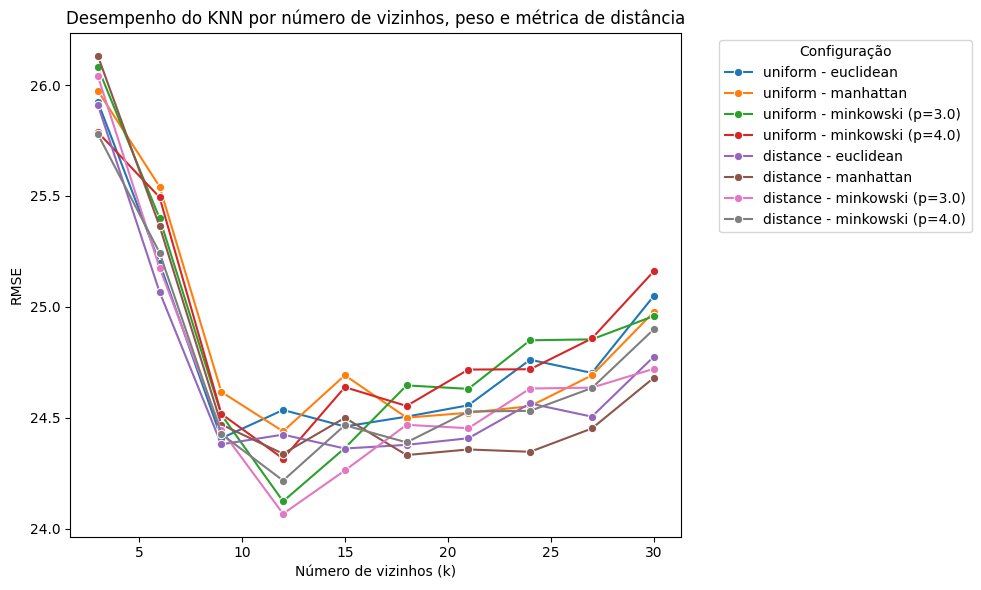

In [10]:
df_resultados["combinacao"] = df_resultados.apply(
    lambda row: f"{row['weights']} - {row['metric']}" + (f" (p={row['p']})" if pd.notna(row['p']) else ""), 
    axis=1)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_resultados,
    x="n_neighbors",
    y="RMSE do modelo",
    hue="combinacao",
    marker="o"
)

plt.xlabel("Número de vizinhos (k)")
plt.ylabel("RMSE")
plt.title("Desempenho do KNN por número de vizinhos, peso e métrica de distância")
plt.legend(title="Configuração", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Com o gráfico acima, fica fácil perceber que há uma queda acentuada no RMSE de `k = 3` até `k = 9-12`, onde todas as curvas despencam juntas nesse trecho, evidenciando que poucos vizinhos deixam o modelo com uma alta variância (sensível a ruído). É possível notar, também, que a maioria das curvas atinge o menor RMSE na faixa de `k = 12-15`, com destaque para a combinação `distance` + `minkowski (p=3)`, que chega ao ponto mais baixo do gráfico inteiro, com k = 12. Como já havia sido comentado anteriormente, nota-se que k grande demais não é sempre melhor, o que pode ser observado ao ver que depois de um certo ponto, aumentar o k volta a piorar o desempenho, tornando o modelo altamente enviesado. Por fim, analisando as curvas, percebe-se que `weights = distance` desempenha melhor que `uniform` nas regiões de k mais alto, o que faz sentido, visto que dar mais peso aos vizinhos mais próximos ajuda a evitar que o ruído dos vizinhos distantes afete a previsão.

##### **Gráfico target real vs previsto**

Vamos fazer agora um gráfico comparando o `attack` real com o `attack` previsto para o melhor modelo (`k=12`, `weights=distance`, `metric=minkowski`, `p=3`) para analisar visualmente a qualidade das previsões de forma individual, observando onde e como o nosso modelo erra.

Na célula abaixo, vamos treinar o melhor modelo que encontramos:

In [11]:
# Criando instância
melhor_modelo = KNeighborsRegressor(
    n_neighbors=12,
    weights="distance",
    metric="minkowski",
    p=3
)

# Ajustando o melhor modelo aos dados
melhor_modelo.fit(X_treino, y_treino)
# Prevendo target
y_previsto_melhor = melhor_modelo.predict(X_teste)

Observe abaixo o gráfico gerado a partir de uma adaptação de um gráfico feito pelo Prof. Doutor Daniel Roberto Cassar no notebook **ATP-203 3.0 - Modelo linear e baseline**:

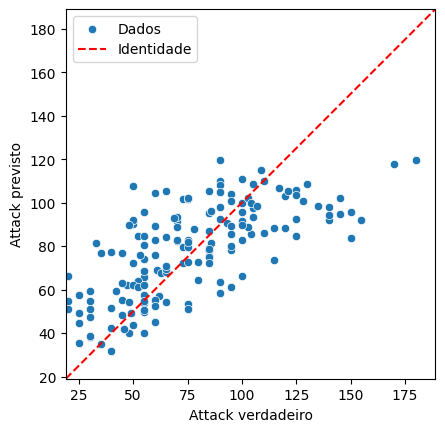

In [12]:
min_val = min(y_teste.min(), y_previsto_melhor.min())
max_val = max(y_teste.max(), y_previsto_melhor.max())

intervalo = [min_val * 0.95, max_val * 1.05]

eixo = sns.scatterplot(x=y_teste, y=y_previsto_melhor, label="Dados")
eixo.plot(intervalo, intervalo, "r--", label="Identidade")

eixo.set(
    xlabel="Attack verdadeiro",
    ylabel="Attack previsto",
    xlim=intervalo,
    ylim=intervalo,
    aspect="equal",
)
eixo.legend()

Analisando o gráfico acima, é possível notar que no meio da distribuição (com attack entre 50 - 100) o modelo vai bem, com os pontos ficando razoavelmente próximos da linha vermelha nessa faixa, o que pode ser explicado pelo fato de ser a região onde o modelo tem mais exemplos de treino similares para se basear, tornando a previsão mais confiável. Por outro lado, observa-se como o modelo falha claramente nos extremos onde, nas regiões de attack baixo (na esquerda, entre ~20-40) os pontos ficam acima da linha, mostrando que o modelo **superestima** a previsão, e nas regiões de attack alto (na direita, entre ~150-180) os pontos ficam abaixo da linha, mostrando que o modelo **subestima** a previsão. Para o algoritmo KNN isso faz sentido, pois como a previsão é uma média dos k vizinhos mais próximos, outliers (valores extremos) tendem a ser puxados na direção da média geral do dataset.

#### **Comparação com modelo baseline**

Vamos agora comparar o desempenho do nosso modelo com relação a um modelo baseline. O modelo baseline é o modelo mais simples que pode ser feito que, no caso de problemas de regressão (como o nosso), utiliza a média dos valores históricos como previsão padrão (ignora todos os outros atributos). Ou seja, ele é um modelo que serve apenas como ponto de referência para comparar com outros modelos e não deve ser utilizado para problemas reais. Por isso que um modelo com desempenho pior que o do baseline é considerado um modelo bem ruim.

Na célula abaixo, vamos treinar o modelo baseline utilizando a função `DummyRegressor` do scikit-learn:

In [13]:
# Criando instância
modelo_baseline = DummyRegressor()
# Ajustando modelo aos dados
modelo_baseline.fit(X_treino, y_treino)
# Prevendo target
y_previsto_baseline = modelo_baseline.predict(X_teste)

Cálculo do RMSE do modelo baseline e do melhor modelo que obtivemos:

In [14]:
RMSE_baseline = root_mean_squared_error(y_teste, y_previsto_baseline)
RMSE_melhor_modelo = root_mean_squared_error(y_teste, y_previsto_melhor)

print(f'-------------RMSEs-------------')
print(f'RMSE do modelo baseline: {RMSE_baseline:.2f}')
print()
print(f'RMSE do melhor modelo: {RMSE_melhor_modelo:.2f}')


-------------RMSEs-------------
RMSE do modelo baseline: 33.04

RMSE do melhor modelo: 24.07


Observe que o RMSE do modelo baseline é maior que o do melhor modelo que obtivemos anteriormente, o que é algo bom e significa que nosso modelo não é tão ruim!

Veja, de forma visual, essa diferença a partir de um gráfico de barras gerado com auxílio do Claude:

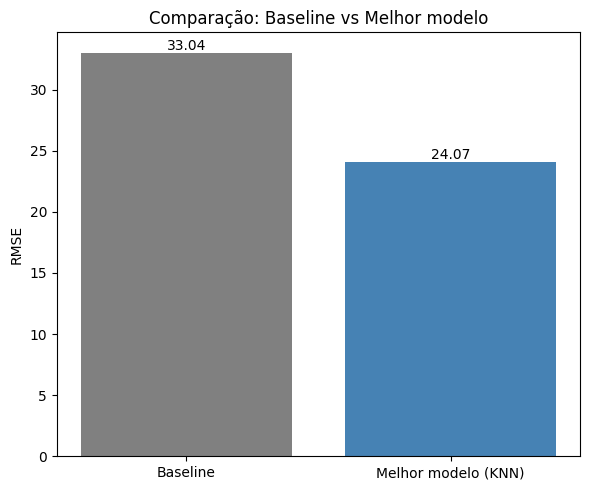

In [15]:
modelos = ['Baseline', 'Melhor modelo (KNN)']
valores_rmse = [RMSE_baseline, RMSE_melhor_modelo]

plt.figure(figsize=(6, 5))
barras = plt.bar(modelos, valores_rmse, color=['gray', 'steelblue'])

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura, f'{altura:.2f}',
              ha='center', va='bottom')

plt.ylabel('RMSE')
plt.title('Comparação: Baseline vs Melhor modelo')
plt.tight_layout()
plt.show()

Vamos calcular a redução no erro (em %) em relação ao modelo baseline:

In [16]:
percentual_reducao = ((RMSE_baseline - RMSE_melhor_modelo)/RMSE_baseline) * 100

print(f'O RMSE do melhor modelo apresentou uma redução em relação ao modelo baseline de aproximademente {percentual_reducao:.2f}%')

O RMSE do melhor modelo apresentou uma redução em relação ao modelo baseline de aproximademente 27.15%


Ou seja, o nosso modelo KNN está de fato capturando uma relação entre os atributos (stats e tipo) e o attack dos pokémons, superando a previsão do baseline, que ignora completamente essa informação. No entanto, vale notar que o RMSE do melhor modelo KNN que obtivemos não é próximo de zero, o que pode ser explicado pela dificuldade que o modelo tem em capturar outliers de attack como observado no gráfico de valores reais vs previstos, e porque o attack de um pokémon provavelmente depende de outros fatores não incluídos neste dataset simplificado.

### **Conclusões e principais aprendizados**

Finalmente concluimos a captura da criatura lendária Cubo Gelatinoso. No processo de captura da criatura, foi treinado modelos de k vizinhos mais próximos para prever o atributo `attack` de pokémons a partir de outras stats (`hp`, `defense`, `sp_attack`, `sp_defense` e `speed`) e do tipo primário (`type1`). Foram testados 80 conjuntos de hiperparâmetros, variando o número de vizinhos (k; de 3 até 30), o tipo de peso (`uniform` e `distance`) e a métrica de distância (`euclidean`, `manhattan` e `minkowski` com diferentes valores de `p`). <br><br> Observando os modelos treinados, o melhor conjunto encontrado foi com k=12, `weights="distance"` e `metric="minkowski"` com `p=3`, alcançando um RMSE de aproximadamente 24.07 no conjuntos de teste. Esse resultado apresentou uma melhora de cerca de 27% em relação a um modelo baseline que prevê sempre a média do `attack` (RMSE de 33.04), confirmando que o modelo captura uma relação real entre os atributos utilizados e o target, mesmo que essa relação esteja longe de ser perfeita. <br><br> Analisando o gráfico de valores reais vs previstos, foi possível perceber uma limitação importante, que é tendência do nosso modelo em superestimar pokémons com attack muito baixo e subestimar pokémons com attack muito alto. Isso se deve, provavelmente, pelo fato de que no KNN, em problemas de regressão, a previsão é uma média dos vizinhos mais próximos e outiliers (por serem uma quantidade muito inferior) acabam sendo puxados em direção à média geral. Além disso, fatores não presentes nesse dataset como o papel estratégico do pokémon (se ele é tanque (defesa alta, ataque baixo), de ataque (ataque alto, defesa baixa) ou suporte) e se ele é lendário ou não, possivelmente também influenciam no attack. <br><br> Com relação ao comportamento dos hiperparâmetros, foi possível observar que o RMSE caiu de forma acentuada entre k=3 e k=9, se manteve relativamente estável (com pequenas variações) entre k=9 e k=18, e voltou a subir gradualmente para valores de k maiores. Isso ilustra bem a relação entre viés e variância que a diretora da Biblioteca Real, Diana Didatolov, explicou para mim em minha jornada em busca do Cubo Gelatinoso, onde valores pequenos de k tornam o modelo mais sobreajustado (alta variância), enquanto valores muito altos generalizam demais, tornando o modelo subajustado (alto viés). <br><br> De forma geral, a captura da criatura foi extremamente útil para aumentar meus pontos de inteligência e experiência, fazendo com que eu entendesse, na prática, os limites do KNN como modelo preditivo, sendo um algoritmo simples, mas sensível à escolha de hiperparâmetros e sujeito a um viés estrutural em relação a valores extremos do target. Agora me sinto capaz de enfrentar qualquer monstro ou capturar qualquer criatura que envolva o treino de modelos de algoritmo KNN, visto que agora sei como variar conjuntos de hiperparâmetros, tratar dados, comparar com modelos baseline e observar graficamente os resultados.

### **Descrição do uso de IA neste trabalho**

Durante a realização deste trabalho, utilizei o Claude (Anthropic) como apoio em diferentes etapas do processo. Ele me ajudou a simplificar o dataset original, selecionando apenas as colunas relevantes (type1, stats e geração), e discutiu comigo decisões de pré-processamento, como o descarte da coluna type2 por conter muitos valores faltantes. Pedi explicações conceituais sobre o parâmetro weights do KNN, sobre as métricas de distância chebyshev e minkowski (incluindo o papel do parâmetro p), e sobre como usar itertools.product para gerar automaticamente as combinações de hiperparâmetros a testar, sem escrever cada uma manualmente. Também usei a IA para interpretar um RMSE maior em k=5 do que em k=3, o que me ajudou a entender melhor o trade-off entre viés e variância do algoritmo. Por fim, pedi ajuda direta de código apenas para duas partes específicas, sendo elas a construção do gráfico de linha no seaborn comparando RMSE por combinação de hiperparâmetros, e o gráfico de barras comparando o modelo final com o baseline. Todas as decisões de modelagem, a escrita das análises e a conclusão do notebook foram feitas por mim.

*Link da conversa com a IA:* https://claude.ai/share/ab9e5637-523d-42d4-a852-a29b7df4915f

### **Referências**

https://www.kaggle.com/datasets/rounakbanik/pokemon [1]

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html

https://en.wikipedia.org/wiki/Metric_space

https://en.wikipedia.org/wiki/Minkowski_distance

*Notebooks utilizados como referência:*

CASSAR, Daniel Roberto. **ATP-203 1.1 - Tratamento de dados com pandas**

CASSAR, Daniel Roberto. **ATP-203 2.1 - Aprendizado de máquina, k-NN e métricas**

CASSAR, Daniel Roberto. **ATP-203 2.2 - Divisão de dados em treino e teste**

CASSAR, Daniel Roberto. **ATP-203 3.0 - Modelo linear e baseline**